A RNN model For Text Classification
- given a input english sentence.
- i want to classify it into these Tags.
    --"definition",
    --"cause",
    --"symptom",
    --"prevention",
    --"food",
    --"medicine",
    --"post-recovery",
    -- None (this category says, input belongs to nothing. and handle separately.)

In [1]:
import torch

# Check if GPU is available
print("CUDA available:", torch.cuda.is_available())

# Get CUDA version
print("CUDA version:", torch.version.cuda)

# Get PyTorch version
print("PyTorch version:", torch.__version__)

# If GPU is available, check device name
if torch.cuda.is_available():
    print("GPU device:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())

CUDA available: True
CUDA version: 13.0
PyTorch version: 2.12.0+cu130
GPU device: NVIDIA GeForce RTX 2050
GPU count: 1


In [2]:
import os, pickle, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
SEED = 42
MAX_VOCAB = 30000
MAX_LEN = 64
EMBED_DIM = 128
LSTM_UNITS = 128
DENSE_UNITS = 128
DROPOUT = 0.4
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-3
SAVE_DIR = "bilstm_model"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Using device: cuda


In [4]:
LABEL2ID = {
    "symptoms":0,"cause":1,"prevention":2,
    "definition":3,"medicine":4,"food":5,"post-recovery":6
}
ID2LABEL = {v:k for k,v in LABEL2ID.items()}
NUM_CLASSES = len(LABEL2ID)

In [5]:
MAPPING = {
    "symptoms":                               "symptom",
    "causes":                                 "cause",
    "prevention":                             "prevention",
    "precautions":                            "prevention",
    "information":                            "definition",
    "indication":                             "definition",
    "how does it work":                       "definition",
    "stages":                                 "definition",
    "treatment":                              "medicine",
    "usage":                                  "medicine",
    "dose":                                   "medicine",
    "side effects":                           "medicine",
    "interactions with medications":          "medicine",
    "interactions with foods":                "medicine",
    "interactions with herbs and supplements":"medicine",
    "brand names":                            "medicine",
    "brand names of combination products":    "medicine",
    "storage and disposal":                   "medicine",
    "forget a dose":                          "medicine",
    "emergency or overdose":                  "medicine",
    "contraindication":                       "medicine",
    "dietary":                                "food",
    "outlook":                                "post-recovery",
    "complications":                          "post-recovery",
    "considerations":                         "post-recovery",
}

In [6]:
def load_and_prepare():
    df=pd.read_csv('dataset.csv')

    df["tags"] = df["tags"].str.lower().str.strip()
    df["label"] = df["tags"].map(LABEL2ID)

    df["text"] = df["questions"].fillna("").str.strip()
    df = df[df["text"].str.len() > 5].reset_index(drop=True)

    return df[["text","label"]]

In [7]:
class Vocab:
    def __init__(self, max_vocab=MAX_VOCAB):
        self.word2idx = {"<PAD>":0,"<OOV>":1}
        self.idx2word = {0:"<PAD>",1:"<OOV>"}
        self.max_vocab = max_vocab

    def build(self, texts):
        freq = {}
        for text in texts:
            for w in text.lower().split():
                freq[w] = freq.get(w,0)+1

        sorted_words = sorted(freq.items(), key=lambda x:-x[1])
        for i,(w,_) in enumerate(sorted_words[:self.max_vocab-2], start=2):
            self.word2idx[w]=i
            self.idx2word[i]=w

    def encode(self, text):
        return [self.word2idx.get(w,1) for w in text.lower().split()]

In [8]:
def pad(seq):
    if len(seq) >= MAX_LEN:
        return seq[:MAX_LEN]
    return seq + [0]*(MAX_LEN-len(seq))

In [9]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, vocab):
        self.X = [pad(vocab.encode(t)) for t in texts]
        self.y = labels

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])

In [10]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim)
        self.V = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        score = torch.tanh(self.W(x))
        weights = torch.softmax(self.V(score), dim=1)
        context = torch.sum(weights * x, dim=1)
        return context

In [11]:
class BiLSTM_Attention(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, EMBED_DIM, padding_idx=0)

        self.lstm = nn.LSTM(
            EMBED_DIM,
            LSTM_UNITS,
            batch_first=True,
            bidirectional=True,
            num_layers=2,
            dropout=0.3
        )

        self.attn = Attention(LSTM_UNITS*2)

        self.fc = nn.Sequential(
            nn.Linear(LSTM_UNITS*2, DENSE_UNITS),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(DENSE_UNITS, DENSE_UNITS//2),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(DENSE_UNITS//2, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.embedding(x)
        x,_ = self.lstm(x)
        x = self.attn(x)
        x = self.fc(x)
        return x

In [12]:
def train(df):
    texts = df["text"].tolist()
    labels = df["label"].tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        texts, labels, test_size=0.15, stratify=labels, random_state=SEED)

    vocab = Vocab()
    vocab.build(X_train)

    train_ds = TextDataset(X_train, y_train, vocab)
    test_ds = TextDataset(X_test, y_test, vocab)

    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE)

    model = BiLSTM_Attention(len(vocab.word2idx)).to(device)

    # class weights
    cw = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_train)
    cw = torch.tensor(cw, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=cw)
    optimizer = optim.Adam(model.parameters(), lr=LR)

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for X,y in train_loader:
            X,y = X.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out,y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    return model, vocab, test_loader

In [13]:
def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for X,y in loader:
            X = X.to(device)
            out = model(X)
            pred = torch.argmax(out, dim=1).cpu().numpy()

            y_pred.extend(pred)
            y_true.extend(y.numpy())

    print(classification_report(y_true, y_pred, target_names=ID2LABEL.values()))


In [14]:
def encode_with_oov(text, vocab):
    tokens = text.lower().split()
    encoded = []
    oov_count = 0

    for w in tokens:
        if w in vocab.word2idx:
            encoded.append(vocab.word2idx[w])
        else:
            encoded.append(1)  # <OOV>
            oov_count += 1

    return encoded, oov_count, len(tokens)

In [15]:
import math

def compute_entropy(probs):
    return -torch.sum(probs * torch.log(probs + 1e-10)).item()

def predict(
    text,
    model,
    vocab,
    max_len=64,
    oov_threshold=0.25,
    confidence_threshold=0.6,
    entropy_threshold=1.5,
    temperature=2.0
):
    model.eval()

    # ─────────────────────────────
    # 1. Tokenize + OOV check
    # ─────────────────────────────
    tokens = text.lower().split()
    encoded = []
    oov_count = 0

    for w in tokens:
        if w in vocab.word2idx:
            encoded.append(vocab.word2idx[w])
        else:
            encoded.append(1)  # <OOV>
            oov_count += 1

    total_tokens = max(len(tokens), 1)
    oov_ratio = oov_count / total_tokens

    # 🚫 OOV REJECTION
    if oov_ratio > oov_threshold:
        return {
            "label": "none",
            "confidence": 0.0,
            "reason": f"OOV ratio too high ({oov_ratio:.2f})"
        }

    # ─────────────────────────────
    # 2. Padding
    # ─────────────────────────────
    seq = encoded[:max_len] + [0] * (max_len - len(encoded))
    x = torch.tensor([seq]).to(next(model.parameters()).device)

    # ─────────────────────────────
    # 3. Model prediction
    # ─────────────────────────────
    with torch.no_grad():
        logits = model(x)

        # 🔥 Temperature scaling
        logits = logits / temperature

        probs = torch.softmax(logits, dim=1)[0]

    confidence, label_id = torch.max(probs, dim=0)
    entropy = compute_entropy(probs)

    # ─────────────────────────────
    # 4. REJECTION LOGIC
    # ─────────────────────────────

    # 🚫 Low confidence
    if confidence.item() < confidence_threshold:
        return {
            "label": "none",
            "confidence": float(confidence),
            "reason": f"Low confidence ({confidence:.2f})"
        }

    # 🚫 High uncertainty (entropy)
    if entropy > entropy_threshold:
        return {
            "label": "none",
            "confidence": float(confidence),
            "reason": f"High entropy ({entropy:.2f})"
        }

    # ✅ Accept prediction
    return {
        "label": ID2LABEL[label_id.item()],
        "confidence": float(confidence),
        "entropy": float(entropy),
        "oov_ratio": float(oov_ratio),
        "all_probs": {
            ID2LABEL[i]: round(float(p), 4)
            for i, p in enumerate(probs)
        }
    }

In [16]:
def predict(text, model, vocab):
    model.eval()
    seq = torch.tensor([pad(vocab.encode(text))]).to(device)

    with torch.no_grad():
        out = model(seq)
        prob = torch.softmax(out, dim=1)[0]

    label = torch.argmax(prob).item()
    return ID2LABEL[label], prob[label].item()

In [17]:
df = load_and_prepare()

In [18]:
df.head()

,text,label
0,What is anemia?,3
1,Define anemia,3
2,Low hemoglobin meaning,3
3,What does it mean to be anemic?,3
4,What causes anemia?,1


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 619 entries, 0 to 618
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    619 non-null    str  
 1   label   619 non-null    int64
dtypes: int64(1), str(1)
memory usage: 25.8 KB


In [20]:
model, vocab, test_loader = train(df)

Epoch 1, Loss: 33.1196
Epoch 2, Loss: 33.0681
Epoch 3, Loss: 30.8999
Epoch 4, Loss: 24.3858
Epoch 5, Loss: 19.8362
Epoch 6, Loss: 15.4128
Epoch 7, Loss: 10.9822
Epoch 8, Loss: 9.1052
Epoch 9, Loss: 7.3224
Epoch 10, Loss: 6.1623
Epoch 11, Loss: 4.8964
Epoch 12, Loss: 3.2957
Epoch 13, Loss: 2.3646
Epoch 14, Loss: 1.9941
Epoch 15, Loss: 1.2216
Epoch 16, Loss: 1.0208
Epoch 17, Loss: 1.0737
Epoch 18, Loss: 0.8911
Epoch 19, Loss: 0.5638
Epoch 20, Loss: 0.5607


In [21]:
evaluate(model, test_loader)

               precision    recall  f1-score   support

     symptoms       0.90      0.60      0.72        15
        cause       0.43      0.86      0.57        14
   prevention       0.77      0.71      0.74        14
   definition       0.90      0.64      0.75        14
     medicine       0.75      0.60      0.67        15
         food       1.00      0.64      0.78        14
post-recovery       0.45      0.71      0.56         7

     accuracy                           0.68        93
    macro avg       0.74      0.68      0.68        93
 weighted avg       0.77      0.68      0.69        93



In [22]:
print("\nInference:")
print(predict("What causes malaria?", model, vocab))


Inference:
('cause', 0.9999314546585083)


In [23]:
model.eval()

example_input = torch.randint(0, 100, (1, MAX_LEN)).to(device)

traced_model = torch.jit.trace(model, example_input)

torch.jit.save(traced_model, "bilstm_model/model.pt")

print("TorchScript model saved at bilstm_model/model.pt")

TorchScript model saved at bilstm_model/model.pt


In [24]:
with open("bilstm_model/vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)

# Save config
config = {
    "max_len": MAX_LEN,
    "labels": ID2LABEL
}

with open("bilstm_model/config.pkl", "wb") as f:
    pickle.dump(config, f)

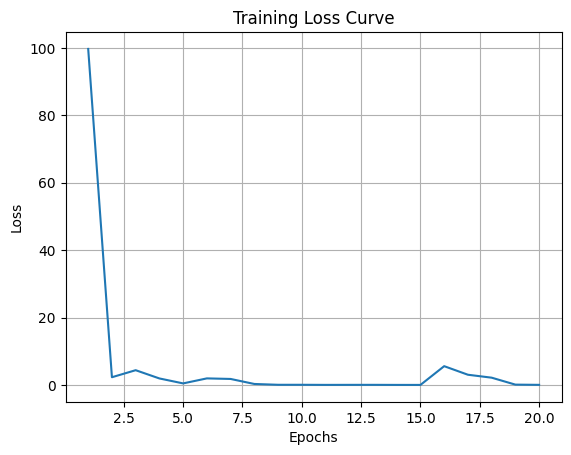

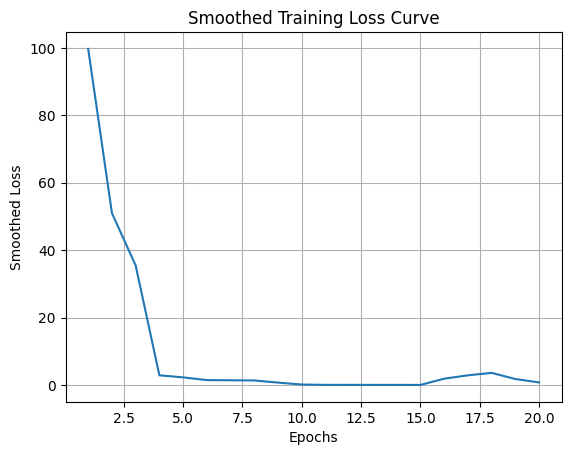

In [25]:
import matplotlib.pyplot as plt

# Given loss values
loss = [
99.7056, 2.2843, 4.3721, 1.9230, 0.4525,
1.9397, 1.7729, 0.2846, 0.0409, 0.0407,
0.0119, 0.0202, 0.0251, 0.0058, 0.0016,
5.5661, 3.0236, 2.1513, 0.0896, 0.0223
]

epochs = list(range(1, 21))

# Plot 1: Training Loss
plt.figure()
plt.plot(epochs, loss)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

# Plot 2: Smoothed Loss (moving average)
window = 3
smoothed = [sum(loss[max(0,i-window+1):i+1])/len(loss[max(0,i-window+1):i+1]) for i in range(len(loss))]

plt.figure()
plt.plot(epochs, smoothed)
plt.xlabel("Epochs")
plt.ylabel("Smoothed Loss")
plt.title("Smoothed Training Loss Curve")
plt.grid(True)
plt.show()

In [26]:
def predict(text, model, vocab, threshold=0.6, temperature=2.0):
    model.eval()
    seq = torch.tensor([pad(vocab.encode(text))]).to(device)

    with torch.no_grad():
        logits = model(seq)

        # 🔥 temperature scaling
        logits = logits / temperature

        prob = torch.softmax(logits, dim=1)[0]

    conf, label = torch.max(prob, dim=0)

    if conf.item() < threshold:
        return ("none", conf.item())

    return (ID2LABEL[label.item()], conf.item())

In [27]:
print(predict("What causes malaria?", model, vocab))        # Expected: cause
print(predict("What are the symptoms of flu?", model, vocab))  # Expected: symptom
print(predict("How can I prevent dengue?", model, vocab))   # Expected: prevention
print(predict("What is diabetes?", model, vocab))           # Expected: definition
print(predict("What medicine is used for fever?", model, vocab))  # Expected: medicine
print(predict("What foods are good for health?", model, vocab))   # Expected: food
print(predict("What should I do after recovery?", model, vocab))  # Expected: post-recovery

('cause', 0.9857215881347656)
('symptoms', 0.9901494979858398)
('prevention', 0.7993489503860474)
('definition', 0.9603279829025269)
('cause', 0.7997288107872009)
('food', 0.9794455170631409)
('post-recovery', 0.9942207336425781)


In [28]:
print(predict("Malaria is caused by parasites transmitted by mosquitoes.", model, vocab))  
# Expected: cause

print(predict("Fever, chills, and sweating are common in malaria.", model, vocab))  
# Expected: symptom

print(predict("Using mosquito nets helps avoid malaria infection.", model, vocab))  
# Expected: prevention

print(predict("Diabetes is a disease that affects blood sugar levels.", model, vocab))  
# Expected: definition

print(predict("Paracetamol is commonly used to reduce fever.", model, vocab))  
# Expected: medicine

print(predict("Eating green vegetables improves immunity.", model, vocab))  
# Expected: food

print(predict("After illness, proper rest is necessary for recovery.", model, vocab))  
# Expected: post-recovery

('cause', 0.9759765267372131)
('cause', 0.9207955598831177)
('cause', 0.7765498161315918)
('cause', 0.9660653471946716)
('cause', 0.6363964080810547)
('cause', 0.9798495769500732)
('post-recovery', 0.948104739189148)


In [29]:
print(predict("This disease spreads through contaminated water.", model, vocab))  
# Expected: cause

print(predict("High temperature and fatigue are observed in patients.", model, vocab))  
# Expected: symptom

print(predict("Regular exercise reduces the risk of heart disease.", model, vocab))  
# Expected: prevention

print(predict("It is a chronic condition affecting the lungs.", model, vocab))  
# Expected: definition

print(predict("Doctors prescribe antibiotics for bacterial infections.", model, vocab))  
# Expected: medicine

print(predict("A protein-rich diet helps rebuild muscle strength.", model, vocab))  
# Expected: food

print(predict("Follow-up care is important after surgery.", model, vocab))  
# Expected: post-recovery

('cause', 0.9749913215637207)
('cause', 0.9910802245140076)
('cause', 0.9875613451004028)
('none', 0.5830414295196533)
('cause', 0.9623684883117676)
('post-recovery', 0.9839800596237183)
('post-recovery', 0.9922823309898376)


In [30]:
print(predict("I love playing football.", model, vocab))  
# Expected: none

print(predict("The sky is blue and beautiful.", model, vocab))  
# Expected: none

print(predict("Python is a programming language.", model, vocab))  
# Expected: none

('cause', 0.9602201581001282)
('cause', 0.9311885237693787)
('cause', 0.891962468624115)


In [31]:
print(predict("Vitamin C helps in improving immunity.", model, vocab))  
# Expected: food (sometimes prevention — acceptable confusion)

print(predict("Smoking leads to lung cancer.", model, vocab))  
# Expected: cause

print(predict("Patients may experience nausea and dizziness.", model, vocab))  
# Expected: symptom

print(predict("Rest and hydration are advised after treatment.", model, vocab))  
# Expected: post-recovery

print(predict("This medicine should be taken twice daily.", model, vocab))  
# Expected: medicine

('cause', 0.9515952467918396)
('post-recovery', 0.8182922601699829)
('cause', 0.9745286107063293)
('post-recovery', 0.9857611060142517)
('cause', 0.9751392602920532)


In [32]:
import pickle

# Load model
model = torch.jit.load("bilstm_model/model.pt")
model.eval()

# Load vocab
with open("bilstm_model/vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

In [33]:
predict("Malaria is caused by mosquitoes", model, vocab)

('cause', 0.9481080770492554)

In [34]:
predict("Blockchain uses cryptographic hashing", model, vocab)

('cause', 0.9492406845092773)

In [35]:
predict("Quantum fever causes instability", model, vocab)

('cause', 0.9808027744293213)

In [36]:
predict("I love eating food", model, vocab)

('none', 0.5028817653656006)

In [37]:
predict("Donald Trump eats Expensive Food.", model, vocab)

('cause', 0.9675630331039429)

In [38]:
predict("Hindi is mother tongue of india", model, vocab)

('cause', 0.9682212471961975)